In [10]:
# Import libraries 
import os
import itertools
import math
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from sklearn.metrics import roc_auc_score, mean_squared_error
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
import seaborn as sns

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Constants
CORE_LEN = 9
OUTPUT_SIZE = 1
BLOSUM_FILE = "Data/Matrices/BLOSUM50"
ALPHABET_FILE = "Data/Matrices/alphabet"
BINDER_THRESHOLD = 0.5  

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

PyTorch version: 2.5.1
CUDA available: False


In [11]:
# Verifying data files
DATA_DIR = "Data/Alleles"

if os.path.exists(DATA_DIR):
    alleles = os.listdir(DATA_DIR)
    print(f"Found {len(alleles)} alleles")
    
    # Check A0101 has files
    a0101_dir = os.path.join(DATA_DIR, "A0101")
    if os.path.exists(a0101_dir):
        files = os.listdir(a0101_dir)
        c_files = sorted([f for f in files if f.startswith('c')])
        f_files = sorted([f for f in files if f.startswith('f')])
        print(f"A0101 has {len(files)} files")
        print(f"c files: {c_files}")
        print(f"f files: {f_files}")
    else:
        print("ERROR: A0101 directory not found!")
else:
    print("ERROR: Data directory not found!")

# Check resource files
print("\nChecking resource files...")
for file_path, name in [(BLOSUM_FILE, "BLOSUM"), (ALPHABET_FILE, "Alphabet")]:
    if os.path.exists(file_path):
        print(f"{name} file: {file_path}")
    else:
        print(f"{name} file not found: {file_path}")

Found 36 alleles
A0101 has 11 files
c files: ['c000', 'c001', 'c002', 'c003', 'c004']
f files: ['f000', 'f001', 'f002', 'f003', 'f004']

Checking resource files...
BLOSUM file: Data/Matrices/BLOSUM50
Alphabet file: Data/Matrices/alphabet


In [12]:
# BLOSUM and alphabet loading 
def load_blosum(blosum_file, alphabet_file):
    "Load BLOSUM50 substitution matrix using separate alphabet file."
    # Load alphabet
    with open(alphabet_file, 'r') as f:
        aa = f.read().strip().split()
    aa = [a for a in aa if a and not a.startswith('#')]
    
    print(f"  Loaded {len(aa)} amino acids from alphabet")
    
    # Load BLOSUM matrix (numbers only)
    blosum_numpy = None
    
    # Strategy 1: Read as numbers only
    try:
        lines = []
        with open(blosum_file, 'r') as f:
            for line in f:
                line = line.strip()
                if line and not line.startswith('#'):
                    parts = line.split()
                    try:
                        nums = [float(x) for x in parts]
                        if len(nums) >= len(aa):
                            lines.append(nums[:len(aa)])
                    except ValueError:
                        continue
        if lines:
            blosum_numpy = np.array(lines, dtype=np.float32)
            print(f"  Loaded matrix shape {blosum_numpy.shape}")
    except Exception as e:
        print(f"  Strategy 1 failed: {e}")
    
    # Strategy 2: Fallback to pandas
    if blosum_numpy is None:
        try:
            df = pd.read_csv(blosum_file, sep=r"\s+", comment="#", header=None)
            blosum_numpy = df.to_numpy(dtype=np.float32)
            print(f"  Fallback: loaded shape {blosum_numpy.shape}")
        except Exception as e:
            print(f"  Fallback failed: {e}")
    
    if blosum_numpy is None:
        raise ValueError(f"Could not parse BLOSUM file: {blosum_file}")
    
    # Ensure matrix matches alphabet size
    n_aa = len(aa)
    
    # Pad or truncate as needed
    if blosum_numpy.shape != (n_aa, n_aa):
        new_matrix = np.full((n_aa, n_aa), -1.0, dtype=np.float32)
        rows = min(blosum_numpy.shape[0], n_aa)
        cols = min(blosum_numpy.shape[1], n_aa)
        new_matrix[:rows, :cols] = blosum_numpy[:rows, :cols]
        blosum_numpy = new_matrix
        print(f"  Reshaped matrix to {blosum_numpy.shape}")
    
    blosum_matrix = torch.tensor(blosum_numpy, dtype=torch.float32)
    aa_to_idx = {aa: i for i, aa in enumerate(aa)}
    
    return blosum_matrix, aa_to_idx


def load_peptide_target(filename):
    "Load peptide and target values from a data file."
    try:
        df = pd.read_csv(filename, sep=r"\s+", usecols=[0, 1], names=["peptide", "target"])
        return df.sort_values(by="target", ascending=False).reset_index(drop=True)
    except Exception as e:
        print(f"  Error loading {filename}: {e}")
        raise


def encode_peptides(x_in, blosum_file, alphabet_file, core_len=9):
    "Encode peptides using BLOSUM matrix."
    blosum50, aa_to_idx = load_blosum(blosum_file, alphabet_file)
    
    x_idx = []
    pep_idx = []
    
    for i, peptide in enumerate(x_in["peptide"]):
        for j in range(len(peptide) - core_len + 1):
            core = peptide[j:j + core_len]
            x_idx.append([aa_to_idx.get(aa, aa_to_idx.get('X', 0)) for aa in core])
            pep_idx.append(i)
    
    x_idx = torch.tensor(x_idx, dtype=torch.long)
    x_out = blosum50[x_idx]
    y_out = torch.tensor(x_in["target"].to_numpy(), dtype=torch.float32).reshape(-1, 1)
    pep_idx = torch.tensor(pep_idx, dtype=torch.long).reshape(-1, 1)
    
    return x_out, y_out, pep_idx

In [13]:
# Neural network model
def xavier_initialization_normal(layer_weights):
    return nn.init.xavier_normal_(layer_weights)


class SimpleFFNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, 
                 initialization_function=xavier_initialization_normal):
        super().__init__()
        self.in_layer = nn.Linear(input_size, hidden_size)
        self.out_layer = nn.Linear(hidden_size, output_size)
        self.hidden_act = nn.ReLU()
        self.out_act = nn.Sigmoid()
        
        initialization_function(self.in_layer.weight)
        initialization_function(self.out_layer.weight)
    
    def forward(self, x, pep_idx):
        z1 = self.in_layer(x)
        a1 = self.hidden_act(z1)
        z2 = self.out_layer(a1)
        a2 = self.out_act(z2)
        
        # NNAlign: take max score across all 9-mer cores
        n_peptides = int(pep_idx.max().item()) + 1
        
        a2_best = torch.full(
            size=(n_peptides, a2.shape[1]),
            fill_value=-float("inf"),
            dtype=a2.dtype,
            device=a2.device
        )
        
        a2_best.scatter_reduce_(
            dim=0,
            index=pep_idx.expand(-1, a2.shape[1]),
            src=a2,
            reduce="amax",
            include_self=True
        )
        
        return a2_best

In [14]:
# Training and evaluation functions
def train_network(net, x_train, y_train, pep_idx_train, optimizer):
    net.train()
    loss_fn = nn.MSELoss()
    preds = net(x_train, pep_idx_train)
    loss = loss_fn(preds, y_train)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    return loss.item()


def eval_network(net, x_valid, y_valid, pep_idx_valid):
    net.eval()
    loss_fn = nn.MSELoss()
    with torch.no_grad():
        preds = net(x_valid, pep_idx_valid)
        loss = loss_fn(preds, y_valid)
    return loss.item()


def train_model(train_file, valid_file, hidden_size, learning_rate, 
                weight_decay, patience, seed, blosum_file, alphabet_file,
                epochs=2000, verbose=False):
    """
    Train a model with early stopping.
    """
    torch.manual_seed(seed)
    
    # Load data
    train_raw = load_peptide_target(train_file)
    valid_raw = load_peptide_target(valid_file)
    
    if verbose:
        print(f"  Training data: {len(train_raw)} peptides")
        print(f"  Validation data: {len(valid_raw)} peptides")
    
    # Encode
    x_train, y_train, pep_idx_train = encode_peptides(train_raw, blosum_file, alphabet_file, CORE_LEN)
    x_valid, y_valid, pep_idx_valid = encode_peptides(valid_raw, blosum_file, alphabet_file, CORE_LEN)
    
    x_train = x_train.reshape(x_train.shape[0], -1)
    x_valid = x_valid.reshape(x_valid.shape[0], -1)
    
    # Build model
    input_size = x_train.shape[1]
    model = SimpleFFNN(input_size=input_size, hidden_size=hidden_size, output_size=OUTPUT_SIZE)
    optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    
    # Training loop with early stopping
    best_valid_loss = float('inf')
    best_model_state = None
    best_epoch = 0
    patience_counter = 0
    train_losses = []
    valid_losses = []
    
    for epoch in range(epochs):
        train_loss = train_network(model, x_train, y_train, pep_idx_train, optimizer)
        valid_loss = eval_network(model, x_valid, y_valid, pep_idx_valid)
        
        train_losses.append(train_loss)
        valid_losses.append(valid_loss)
        
        if valid_loss < best_valid_loss:
            best_valid_loss = valid_loss
            best_model_state = model.state_dict().copy()
            best_epoch = epoch
            patience_counter = 0
        else:
            patience_counter += 1
        
        if patience_counter >= patience:
            if verbose:
                print(f"  Early stopping at epoch {epoch} (best: {best_epoch})")
            break
        
        if verbose and (epoch % max(1, epochs // 20) == 0 or epoch == epochs - 1):
            print(f"  Epoch {epoch}: train_loss={train_loss:.6f}, valid_loss={valid_loss:.6f}")
    
    # Load best model
    model.load_state_dict(best_model_state)
    
    return model, best_epoch, best_valid_loss, train_losses, valid_losses

In [15]:
# Prediction and Metrics Functions
def predict(model, test_file, blosum_file, alphabet_file):
    "Make predictions on test data."
    test_raw = load_peptide_target(test_file)
    x_test, y_test, pep_idx_test = encode_peptides(test_raw, blosum_file, alphabet_file, CORE_LEN)
    x_test = x_test.reshape(x_test.shape[0], -1)
    
    model.eval()
    with torch.no_grad():
        preds = model(x_test, pep_idx_test).squeeze(1).cpu().numpy()
    
    result_df = test_raw.copy()
    result_df["prediction"] = preds
    return result_df


def compute_metrics(df, affinity_threshold=BINDER_THRESHOLD):
    "Compute AUC, PCC, and MSE with binder threshold."
    y_true = df['target'].values
    y_pred = df['prediction'].values
    
    # Convert to binary with threshold
    y_true_binary = (y_true >= affinity_threshold).astype(int)
    
    # Compute AUC
    try:
        auc = roc_auc_score(y_true_binary, y_pred)
    except Exception as e:
        print(f"  AUC computation error: {e}")
        auc = float('nan')
    
    # Compute PCC
    try:
        pcc, pcc_pvalue = pearsonr(y_true, y_pred)
    except Exception as e:
        print(f"  PCC computation error: {e}")
        pcc = float('nan')
        pcc_pvalue = float('nan')
    
    # Compute MSE
    mse = mean_squared_error(y_true, y_pred)
    
    return {
        'auc': auc,
        'pcc': pcc,
        'pcc_pvalue': pcc_pvalue,
        'mse': mse,
        'n_samples': len(y_true),
        'n_binders': y_true_binary.sum(),
        'n_nonbinders': len(y_true_binary) - y_true_binary.sum(),
        'binder_threshold': affinity_threshold
    }

In [16]:
# Nested CV Function 
def run_nested_cv(allele_dir, outer_fold, hyperparameter_grid, 
                  patience=20, seed=42, epochs=2000, 
                  blosum_file=BLOSUM_FILE, 
                  alphabet_file=ALPHABET_FILE,
                  binder_threshold=BINDER_THRESHOLD,
                  verbose=False):
    "Run nested CV for a single outer fold. FIXED: Concatenates ALL training folds for final model training."
    # Set random seed
    torch.manual_seed(seed)
    np.random.seed(seed)
    
    # --- OUTER LOOP ---
    test_file = f"{allele_dir}/f{outer_fold:03d}"
    train_fold_files = [f"{allele_dir}/c{i:03d}" for i in range(5) if i != outer_fold]
    
    if verbose:
        print(f"\nOuter fold {outer_fold}")
        print(f"  Training on: {[os.path.basename(f) for f in train_fold_files]}")
        print(f"  Testing on: {os.path.basename(test_file)}")
    
    # Checking test data is loaded
    try:
        test_raw = load_peptide_target(test_file)
        if verbose:
            print(f"  Test file loaded: {len(test_raw)} peptides")
    except Exception as e:
        print(f"  ERROR: Cannot load test file {test_file}: {e}")
        return {
            'outer_fold': outer_fold,
            'best_hidden_size': None,
            'best_learning_rate': None,
            'best_weight_decay': None,
            'best_inner_avg_mse': float('inf'),
            'test_auc': float('nan'),
            'test_pcc': float('nan'),
            'test_mse': float('nan'),
            'test_predictions': None,
            'inner_results': []
        }
    
    # INNER LOOP: Hyperparameter Search
    combos = list(itertools.product(
        hyperparameter_grid['hidden_size'],
        hyperparameter_grid['learning_rate'],
        hyperparameter_grid['weight_decay']
    ))
    
    best_params = None
    best_avg_score = float('inf')
    inner_results = []
    
    for hidden_size, learning_rate, weight_decay in combos:
        inner_scores = []
        
        for inner_val_idx, inner_val_file in enumerate(train_fold_files):
            inner_train_files = [f for i, f in enumerate(train_fold_files) 
                                 if i != inner_val_idx]
            
            # Use the first file for training (simplified for inner loop)
            inner_train_file = inner_train_files[0] if inner_train_files else None
            
            if inner_train_file is None:
                inner_scores.append(float('inf'))
                continue
            
            try:
                if not os.path.exists(inner_train_file) or not os.path.exists(inner_val_file):
                    inner_scores.append(float('inf'))
                    continue
                
                model, best_epoch, best_loss, train_losses, valid_losses = train_model(
                    train_file=inner_train_file,
                    valid_file=inner_val_file,
                    hidden_size=hidden_size,
                    learning_rate=learning_rate,
                    weight_decay=weight_decay,
                    patience=patience,
                    seed=seed + len(inner_results),
                    blosum_file=blosum_file,
                    alphabet_file=alphabet_file,
                    epochs=epochs,
                    verbose=False
                )
                
                val_predictions = predict(model, inner_val_file, blosum_file, alphabet_file)
                metrics = compute_metrics(val_predictions, affinity_threshold=binder_threshold)
                inner_scores.append(metrics['mse'])
                
            except Exception as e:
                if verbose:
                    print(f"  ERROR for h={hidden_size}, lr={learning_rate}, wd={weight_decay}: {str(e)[:100]}")
                inner_scores.append(float('inf'))
        
        avg_score = np.mean(inner_scores) if inner_scores else float('inf')
        
        inner_results.append({
            'hidden_size': hidden_size,
            'learning_rate': learning_rate,
            'weight_decay': weight_decay,
            'avg_mse': avg_score
        })
        
        if verbose:
            print(f"  h={hidden_size}, lr={learning_rate}, wd={weight_decay}: avg_MSE={avg_score:.6f}")
        
        if avg_score < best_avg_score:
            best_avg_score = avg_score
            best_params = (hidden_size, learning_rate, weight_decay)
    
    # If all failed, use default parameters
    if best_params is None:
        print(f"  WARNING: All hyperparameter combinations failed! Using defaults.")
        best_params = (25, 0.01, 0.0001)
        best_avg_score = float('inf')
    
    if verbose:
        print(f"  Best params: h={best_params[0]}, lr={best_params[1]}, wd={best_params[2]}")
    
    # OUTER LOOP: Train with best params on ALL training folds 
    hidden_size, learning_rate, weight_decay = best_params
    
    try:
        # FIX: Concatenate ALL training folds
        all_train_dfs = []
        for train_file in train_fold_files:
            if os.path.exists(train_file):
                df = load_peptide_target(train_file)
                all_train_dfs.append(df)
        
        if not all_train_dfs:
            raise ValueError("No training data found!")
        
        final_train_df = pd.concat(all_train_dfs, ignore_index=True)
        
        # Save to temp file for train_model
        os.makedirs("temp", exist_ok=True)
        temp_train_file = f"temp/train_outer{outer_fold}.txt"
        final_train_df.to_csv(temp_train_file, sep=' ', index=False, header=False)
        
        if verbose:
            print(f"  Final training: {len(final_train_df)} peptides from {len(train_fold_files)} folds")
        
        # Use first training fold as validation for early stopping (monitoring only)
        valid_file = train_fold_files[0]
        
        final_model, final_best_epoch, final_best_loss, _, _ = train_model(
            train_file=temp_train_file,
            valid_file=valid_file,
            hidden_size=hidden_size,
            learning_rate=learning_rate,
            weight_decay=weight_decay,
            patience=patience,
            seed=seed + 100,
            blosum_file=blosum_file,
            alphabet_file=alphabet_file,
            epochs=epochs,
            verbose=verbose
        )
        
        # Clean up temp file
        if os.path.exists(temp_train_file):
            os.remove(temp_train_file)
        
        # Test on the held-out outer fold 
        test_predictions = predict(final_model, test_file, blosum_file, alphabet_file)
        test_metrics = compute_metrics(test_predictions, affinity_threshold=binder_threshold)
        
    except Exception as e:
        print(f"  ERROR in final training: {e}")
        test_metrics = {'auc': float('nan'), 'pcc': float('nan'), 'mse': float('nan'), 'n_samples': 0}
        test_predictions = None
    
    return {
        'outer_fold': outer_fold,
        'best_hidden_size': best_params[0],
        'best_learning_rate': best_params[1],
        'best_weight_decay': best_params[2],
        'best_inner_avg_mse': best_avg_score,
        'test_auc': test_metrics.get('auc', float('nan')),
        'test_pcc': test_metrics.get('pcc', float('nan')),
        'test_mse': test_metrics.get('mse', float('nan')),
        'test_predictions': test_predictions,
        'inner_results': inner_results,
        'binder_threshold': binder_threshold
    }

In [17]:
# Nested CV on all 25 alleles 
hyperparameter_grid = {
    'hidden_size': [10, 25, 50, 100],
    'learning_rate': [0.1, 0.01, 0.001],
    'weight_decay': [0.0, 0.0001, 0.001]
}

# Get all available alleles
DATA_DIR = "Data/Alleles"
all_alleles = sorted([d for d in os.listdir(DATA_DIR) if os.path.isdir(os.path.join(DATA_DIR, d))])

print(f"Found {len(all_alleles)} total alleles")

# Select only the first 25 alleles
NUM_ALLELES = 26
selected_alleles = all_alleles[:NUM_ALLELES]

print(f"Selected {len(selected_alleles)} alleles: {selected_alleles}")


# Results container
all_allele_results = []

for allele_idx, allele in enumerate(selected_alleles):
    print(f"Processing allele {allele_idx+1}/{len(selected_alleles)}: {allele}")
    
    allele_dir = os.path.join(DATA_DIR, allele)
    
    # Check required files
    files = os.listdir(allele_dir)
    c_files = sorted([f for f in files if f.startswith('c')])
    f_files = sorted([f for f in files if f.startswith('f')])
    
    if len(c_files) < 5 or len(f_files) < 5:
        print(f"  Skipping {allele}: missing fold files (c: {len(c_files)}, f: {len(f_files)})")
        continue
    
    print(f"  Found {len(c_files)} training folds and {len(f_files)} test folds")
    
    # Track results for this allele
    allele_results = []
    
    for outer_fold in range(5):
        print(f"\n Outer fold {outer_fold}")
        
        try:
            result = run_nested_cv(
                allele_dir=allele_dir,
                outer_fold=outer_fold,
                hyperparameter_grid=hyperparameter_grid,
                patience=20,
                seed=42 + outer_fold,
                epochs=2000,
                blosum_file=BLOSUM_FILE,
                alphabet_file=ALPHABET_FILE,
                binder_threshold=BINDER_THRESHOLD,
                verbose=False
            )
            
            if result['test_auc'] is not None and not np.isnan(result['test_auc']):
                allele_results.append({
                    'allele': allele,
                    'fold': outer_fold,
                    'cv_type': 'nested',
                    'best_hidden': result['best_hidden_size'],
                    'best_lr': result['best_learning_rate'],
                    'best_wd': result['best_weight_decay'],
                    'best_inner_mse': result['best_inner_avg_mse'],
                    'auc': result['test_auc'],
                    'pcc': result['test_pcc'],
                    'mse': result['test_mse'],
                    'binder_threshold': BINDER_THRESHOLD
                })
                print(f"    AUC: {result['test_auc']:.4f}, PCC: {result['test_pcc']:.4f}")
            else:
                print(f"    Failed: invalid result")
                
        except Exception as e:
            print(f"    ERROR: {str(e)[:100]}")
    
    # Summarize this allele
    if allele_results:
        df_allele = pd.DataFrame(allele_results)
        avg_auc = df_allele['auc'].mean()
        std_auc = df_allele['auc'].std()
        avg_pcc = df_allele['pcc'].mean()
        std_pcc = df_allele['pcc'].std()
        
        print(f"\n  Summary for {allele}:")
        print(f"    AUC: {avg_auc:.4f} +/- {std_auc:.4f}")
        print(f"    PCC: {avg_pcc:.4f} +/- {std_pcc:.4f}")
        
        all_allele_results.append({
            'allele': allele,
            'n_folds': len(allele_results),
            'avg_auc': avg_auc,
            'std_auc': std_auc,
            'avg_pcc': avg_pcc,
            'std_pcc': std_pcc,
            'min_auc': df_allele['auc'].min(),
            'max_auc': df_allele['auc'].max(),
            'best_hidden_most_common': df_allele['best_hidden'].mode().iloc[0] if not df_allele['best_hidden'].mode().empty else None,
            'best_lr_most_common': df_allele['best_lr'].mode().iloc[0] if not df_allele['best_lr'].mode().empty else None
        })
        
        # Save per-fold results for this allele
        os.makedirs("results/nested_cv", exist_ok=True)
        df_allele.to_csv(f"results/nested_cv/{allele}_per_fold.csv", index=False)
    else:
        print(f"\n  Summary for {allele}: No valid results")
    
    # Save progress after each allele
    if all_allele_results:
        pd.DataFrame(all_allele_results).to_csv("results/nested_cv/all_alleles_progress.csv", index=False)

# Final summary
if all_allele_results:
    final_df = pd.DataFrame(all_allele_results)
    final_df = final_df.sort_values('avg_auc', ascending=False)
    
    print("Summary (First 25 Alleles):")
    print(final_df[['allele', 'avg_auc', 'std_auc', 'avg_pcc']].to_string(index=False))
    
    # Save final results
    os.makedirs("results/nested_cv", exist_ok=True)
    final_df.to_csv("results/nested_cv/all_alleles_final_25.csv", index=False)
    print("\nResults saved to results/nested_cv/all_alleles_final_25.csv")
else:
    print("No results obtained")

Found 36 total alleles
Selected 26 alleles: ['.conda', 'A0101', 'A0201', 'A0202', 'A0203', 'A0206', 'A0301', 'A1101', 'A2301', 'A2402', 'A2403', 'A2601', 'A2902', 'A3001', 'A3002', 'A3101', 'A3301', 'A6801', 'A6802', 'A6901', 'B0702', 'B0801', 'B1501', 'B1801', 'B2705', 'B3501']
Processing allele 1/26: .conda
  Skipping .conda: missing fold files (c: 2, f: 0)
Processing allele 2/26: A0101
  Found 5 training folds and 5 test folds

 Outer fold 0
  Loaded 20 amino acids from alphabet
  Loaded matrix shape (24, 20)
  Reshaped matrix to (20, 20)
  Loaded 20 amino acids from alphabet
  Loaded matrix shape (24, 20)
  Reshaped matrix to (20, 20)


  Loaded 20 amino acids from alphabet
  Loaded matrix shape (24, 20)
  Reshaped matrix to (20, 20)
  Loaded 20 amino acids from alphabet
  Loaded matrix shape (24, 20)
  Reshaped matrix to (20, 20)
  Loaded 20 amino acids from alphabet
  Loaded matrix shape (24, 20)
  Reshaped matrix to (20, 20)
  Loaded 20 amino acids from alphabet
  Loaded matrix shape (24, 20)
  Reshaped matrix to (20, 20)
  Loaded 20 amino acids from alphabet
  Loaded matrix shape (24, 20)
  Reshaped matrix to (20, 20)
  Loaded 20 amino acids from alphabet
  Loaded matrix shape (24, 20)
  Reshaped matrix to (20, 20)
  Loaded 20 amino acids from alphabet
  Loaded matrix shape (24, 20)
  Reshaped matrix to (20, 20)
  Loaded 20 amino acids from alphabet
  Loaded matrix shape (24, 20)
  Reshaped matrix to (20, 20)
  Loaded 20 amino acids from alphabet
  Loaded matrix shape (24, 20)
  Reshaped matrix to (20, 20)
  Loaded 20 amino acids from alphabet
  Loaded matrix shape (24, 20)
  Reshaped matrix to (20, 20)
  Loaded 2

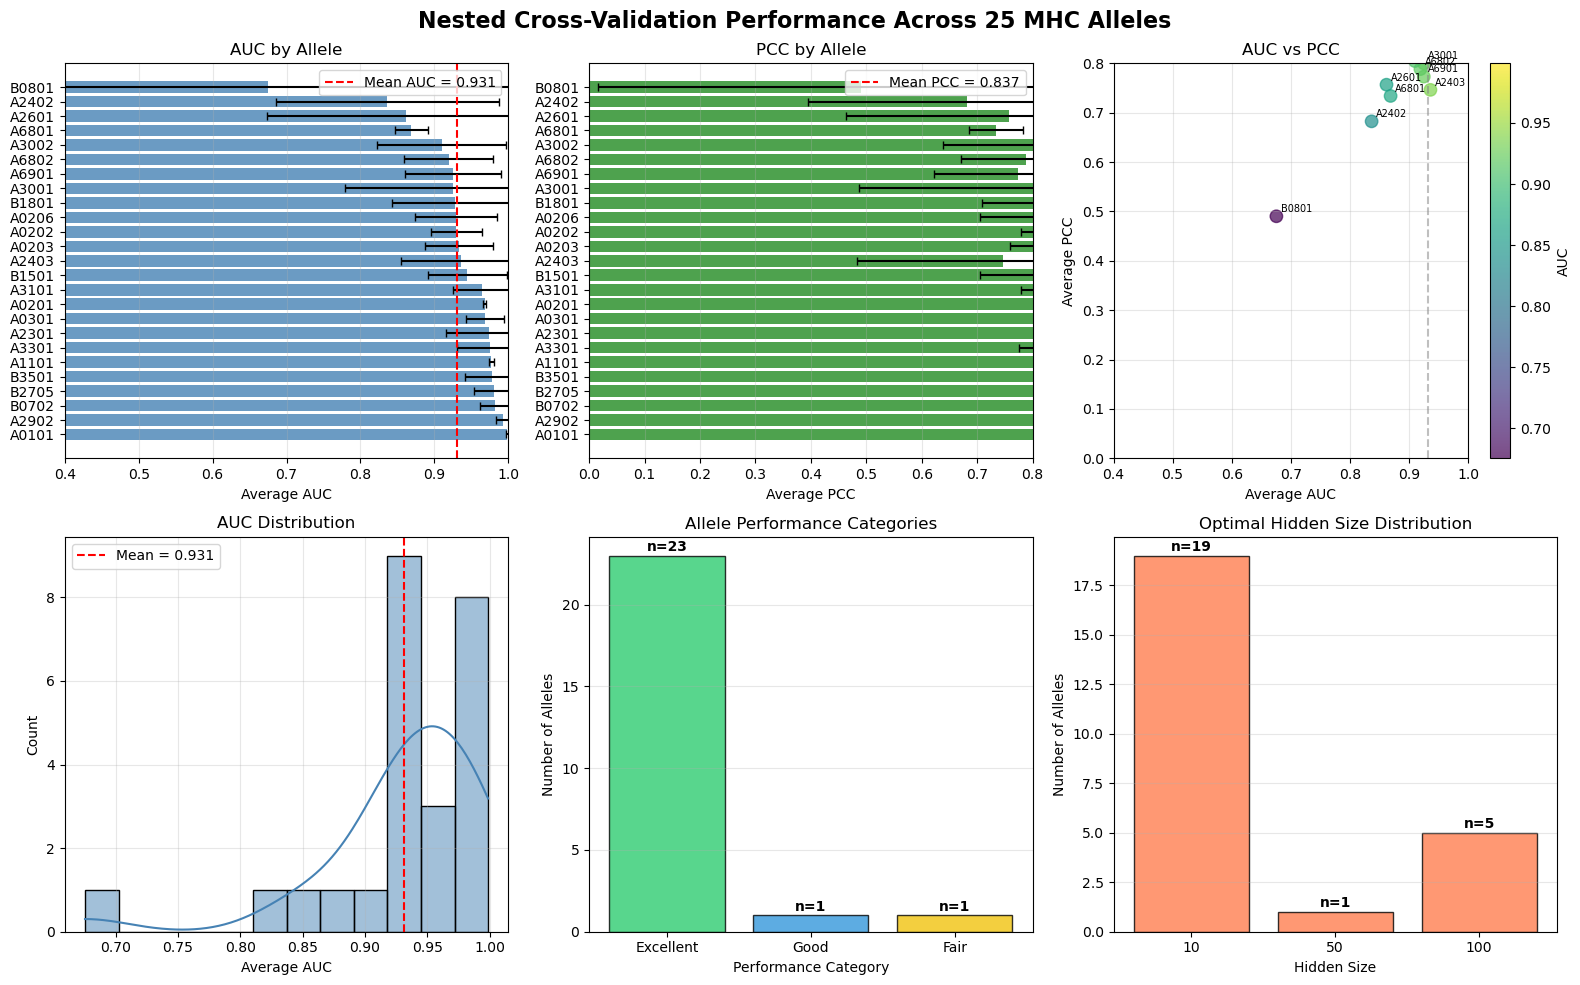

Summary Statistics
Total alleles analyzed: 25
Average AUC: 0.9313 +/- 0.0675
Average PCC: 0.8370 +/- 0.1051
Best: A0101 (AUC: 0.9988)
Worst: B0801 (AUC: 0.6755)


In [19]:
# Display results 
if all_allele_results:
    import matplotlib.pyplot as plt
    import seaborn as sns
    
    results_df = pd.DataFrame(all_allele_results)
    results_df = results_df.sort_values('avg_auc', ascending=False).reset_index(drop=True)
    
    fig, axes = plt.subplots(2, 3, figsize=(16, 10))
    fig.suptitle('Nested Cross-Validation Performance Across 25 MHC Alleles', 
                 fontsize=16, fontweight='bold')
    
    # Plot 1: AUC bar chart
    ax1 = axes[0, 0]
    bars1 = ax1.barh(results_df['allele'], results_df['avg_auc'], 
                     xerr=results_df['std_auc'], color='steelblue', 
                     capsize=3, alpha=0.8)
    ax1.axvline(x=results_df['avg_auc'].mean(), color='red', linestyle='--', 
                label=f"Mean AUC = {results_df['avg_auc'].mean():.3f}")
    ax1.set_xlabel('Average AUC')
    ax1.set_title('AUC by Allele')
    ax1.set_xlim(0.4, 1.0)
    ax1.legend()
    ax1.grid(axis='x', alpha=0.3)
    
    # Plot 2: PCC bar chart
    ax2 = axes[0, 1]
    bars2 = ax2.barh(results_df['allele'], results_df['avg_pcc'], 
                     xerr=results_df['std_pcc'], color='forestgreen', 
                     capsize=3, alpha=0.8)
    ax2.axvline(x=results_df['avg_pcc'].mean(), color='red', linestyle='--', 
                label=f"Mean PCC = {results_df['avg_pcc'].mean():.3f}")
    ax2.set_xlabel('Average PCC')
    ax2.set_title('PCC by Allele')
    ax2.set_xlim(0, 0.8)
    ax2.legend()
    ax2.grid(axis='x', alpha=0.3)
    
    # Plot 3: AUC vs PCC scatter
    ax3 = axes[0, 2]
    scatter = ax3.scatter(results_df['avg_auc'], results_df['avg_pcc'], 
                         s=80, c=results_df['avg_auc'], cmap='viridis', alpha=0.7)
    for _, row in results_df.iterrows():
        ax3.annotate(row['allele'], (row['avg_auc'], row['avg_pcc']), 
                     fontsize=7, xytext=(3, 3), textcoords='offset points')
    ax3.axhline(y=results_df['avg_pcc'].mean(), color='gray', linestyle='--', alpha=0.5)
    ax3.axvline(x=results_df['avg_auc'].mean(), color='gray', linestyle='--', alpha=0.5)
    ax3.set_xlabel('Average AUC')
    ax3.set_ylabel('Average PCC')
    ax3.set_title('AUC vs PCC')
    ax3.set_xlim(0.4, 1.0)
    ax3.set_ylim(0, 0.8)
    ax3.grid(alpha=0.3)
    plt.colorbar(scatter, ax=ax3, label='AUC')
    
    # Plot 4: AUC distribution
    ax4 = axes[1, 0]
    sns.histplot(results_df['avg_auc'], kde=True, color='steelblue', bins=12, ax=ax4)
    ax4.axvline(x=results_df['avg_auc'].mean(), color='red', linestyle='--', 
                label=f"Mean = {results_df['avg_auc'].mean():.3f}")
    ax4.set_xlabel('Average AUC')
    ax4.set_ylabel('Count')
    ax4.set_title('AUC Distribution')
    ax4.legend()
    ax4.grid(alpha=0.3)
    
    # Plot 5: Performance categories
    ax5 = axes[1, 1]
    def cat(auc):
        if auc >= 0.85: return 'Excellent'
        elif auc >= 0.75: return 'Good'
        elif auc >= 0.65: return 'Fair'
        else: return 'Poor'
    results_df['category'] = results_df['avg_auc'].apply(cat)
    counts = results_df['category'].value_counts()
    colors_cat = ['#2ecc71', '#3498db', '#f1c40f', '#e74c3c']
    bars5 = ax5.bar(counts.index, counts.values, color=colors_cat, edgecolor='black', alpha=0.8)
    for bar, count in zip(bars5, counts.values):
        ax5.text(bar.get_x() + bar.get_width()/2, count + 0.1, 
                 f'n={count}', ha='center', va='bottom', fontweight='bold')
    ax5.set_xlabel('Performance Category')
    ax5.set_ylabel('Number of Alleles')
    ax5.set_title('Allele Performance Categories')
    ax5.grid(axis='y', alpha=0.3)
    
    # Plot 6: Hidden size distribution
    ax6 = axes[1, 2]
    hidden_counts = results_df['best_hidden_most_common'].value_counts().sort_index()
    bars6 = ax6.bar(hidden_counts.index.astype(str), hidden_counts.values, 
                    color='coral', edgecolor='black', alpha=0.8)
    for bar, count in zip(bars6, hidden_counts.values):
        ax6.text(bar.get_x() + bar.get_width()/2, count + 0.1, 
                 f'n={count}', ha='center', va='bottom', fontweight='bold')
    ax6.set_xlabel('Hidden Size')
    ax6.set_ylabel('Number of Alleles')
    ax6.set_title('Optimal Hidden Size Distribution')
    ax6.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('results/nested_cv/all_alleles_dashboard.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Print summary
    print("Summary Statistics")
    print(f"Total alleles analyzed: {len(results_df)}")
    print(f"Average AUC: {results_df['avg_auc'].mean():.4f} +/- {results_df['avg_auc'].std():.4f}")
    print(f"Average PCC: {results_df['avg_pcc'].mean():.4f} +/- {results_df['avg_pcc'].std():.4f}")
    print(f"Best: {results_df.iloc[0]['allele']} (AUC: {results_df.iloc[0]['avg_auc']:.4f})")
    print(f"Worst: {results_df.iloc[-1]['allele']} (AUC: {results_df.iloc[-1]['avg_auc']:.4f})")
else:
    print("No results to visualize")